# 10 · Simulating the transmon: from the Cooper-pair box to a pulse train

The theory notebooks of 2024–25 (`simulation/fig0.ipynb`, `frame.ipynb`, `pulse_train.ipynb`, `full_transmon.ipynb`,
`experiment/phase_advance/simulation.ipynb`) built, step by step, a numerical model of what the hardware does to our pulses.
`pulseshop.simulation` keeps the pieces; this notebook walks through them in the order the shop learned them:

1. the Cooper-pair box in the charge basis — why a transmon has a |2⟩ at all (paper Fig. 0);
2. a driven two-level system in the lab frame and in the rotating frame (`frame.ipynb`);
3. the $d$-level standard nonlinear oscillator in the drive frame, Gaussian pulses, pulse trains, DRAG derivative;
4. Rabi oscillation versus amplitude in the 4-level model, with leakage;
5. the "phase advance" seen in simulation: the phase of the amplitude of the undriven level;
6. the master-equation version of the rotation-error sequence (the "3.7 %" fit of the story notebook), at reduced size.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from pulseshop import simulation as sim, io, fitting, qutrit as Q
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pi = np.pi

## 1. The Cooper-pair box (paper Fig. 0)

$H = 4E_C(\hat n - n_g)^2 - E_J\cos\hat\varphi$ in the charge basis $|n\rangle$, $n = -N…N$. With $E_J/E_C = 30$ the lowest eigenstates are
spread over many charge states (charge-insensitive) and their wavefunctions in $\varphi$ are those of a slightly anharmonic oscillator
sitting in the cosine well — the three lowest are our qutrit.

f01 = 14.414 Ec, f12 = 13.177 Ec -> anharmonicity -1.236 Ec ~ -Ec (transmon limit)


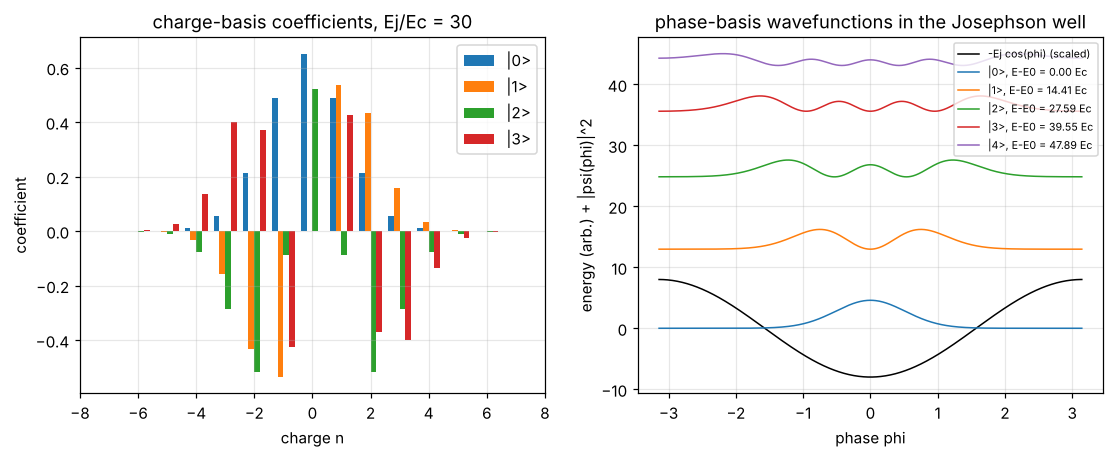

In [2]:
Ec, Ej, N = 1.0, 30.0, 30
evals, coefs = sim.charge_coefficients(Ec, Ej, N, n_states=6)
phi_grid = np.linspace(-pi, pi, 600)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
nn = np.arange(-N, N + 1)
for k in range(4):
    axes[0].bar(nn + 0.2 * k - 0.3, coefs[k], width=0.2, label=f"|{k}>")
axes[0].set(xlim=(-8, 8), xlabel="charge n", ylabel="coefficient", title=f"charge-basis coefficients, Ej/Ec = {Ej/Ec:.0f}"); axes[0].legend()
axes[1].plot(phi_grid, 8 * sim.josephson_potential(phi_grid), "k-", lw=1, label="-Ej cos(phi) (scaled)")
for k in range(5):
    psi = sim.phase_wavefunction(coefs[k], phi_grid, N)
    axes[1].plot(phi_grid, np.abs(psi) ** 2 * 6 + (evals[k] - evals[0]) * 0.9, lw=1, label=f"|{k}>, E-E0 = {evals[k]-evals[0]:.2f} Ec")
axes[1].set(xlabel="phase phi", ylabel="energy (arb.) + |psi(phi)|^2", title="phase-basis wavefunctions in the Josephson well"); axes[1].legend(fontsize=7)
io.save_fig(fig, "10_fig0_cooper_pair_box")
w01 = evals[1] - evals[0]; w12 = evals[2] - evals[1]
print(f"f01 = {w01:.3f} Ec, f12 = {w12:.3f} Ec -> anharmonicity {w12 - w01:.3f} Ec ~ -Ec (transmon limit)")

The 2025 figure used exactly this (`fig0_a.eps` in `figures/paper_2025`). The ratio of the real device, $E_J/E_C = 37$ (notebook 11), is
low for a modern transmon, which gives it an unusually large charge dispersion of the 1–2 transition (notebook 09).

## 2. A driven two-level system: lab frame versus rotating frame (`frame.ipynb`)

/usr/local/lib/python3.13/dist-packages/qutip/core/coefficient.py:199: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your function to the pythonic signature f(t, **kwargs) to maintain compatibility.
  op = FunctionCoefficient(base, args.copy(), style=function_style)


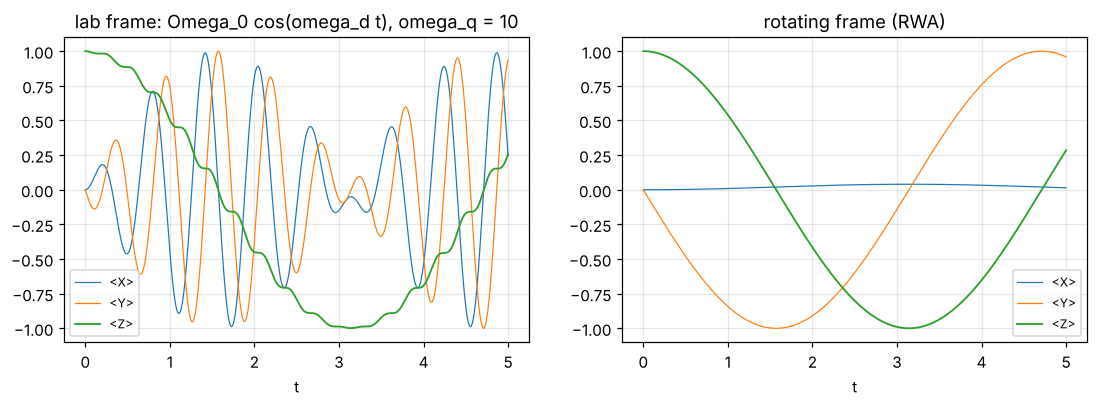

In [3]:
t, X, Y, Z = sim.driven_two_level(omega_q=10, Omega_0=1.0, t_end=5)
t2, X2, Y2, Z2 = sim.driven_two_level(Omega_0=1.0, t_end=5, rotating_frame=True, detuning=0.02)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (tt, xs, ys, zs, title) in zip(axes, [(t, X, Y, Z, "lab frame: Omega_0 cos(omega_d t), omega_q = 10"), (t2, X2, Y2, Z2, "rotating frame (RWA)")]):
    ax.plot(tt, xs, lw=0.8, label="<X>"); ax.plot(tt, ys, lw=0.8, label="<Y>"); ax.plot(tt, zs, lw=1.2, label="<Z>")
    ax.set(xlabel="t", title=title); ax.legend(fontsize=8)
io.save_fig(fig, "10_driven_two_level_frames")

Same physics, two pictures: in the lab frame the Bloch vector spins at $\omega_q$ while slowly tipping (Rabi), in the frame rotating with the
drive only the slow tipping remains. Every pulse parameter in this repository (amplitude, phase, DRAG) refers to the rotating frame.

## 3. The $d$-level transmon under a Gaussian pulse train

$H' = \sum_j [j\delta + \Delta_j]|j\rangle\langle j| + \tfrac{\Omega(t)}{2}\sum_j \lambda_{j-1}(|j\rangle\langle j{-}1| + h.c.)$, with $\Delta_j = \alpha\, j(j-1)/2$
and $\lambda_j$ the relative coupling of each transition ($\sqrt{j+1}$ for a harmonic oscillator; the 2025 fits used 0.54, 0.61, 0.75).
Units: rad/ns, time in ns, so a 20 ns pulse at $f_{01} = 4.985$ GHz and $\alpha = -0.3071$ GHz looks like this:

area of the train: 25.692 rad


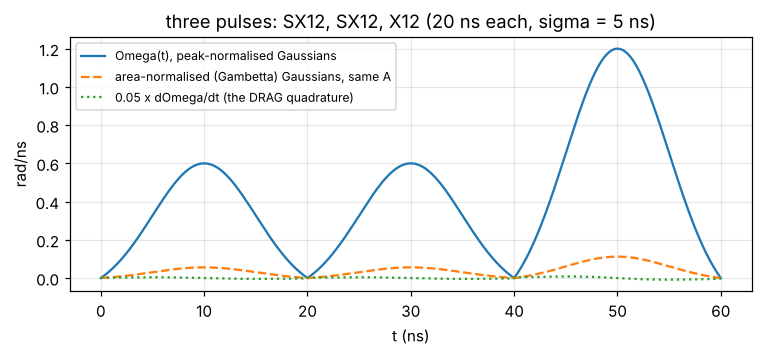

In [4]:
dim = 4
H0, H1 = sim.transmon_frame_hamiltonian(dim, 4.985, -0.3071, lambdas=[0.54, 0.61, 0.75])
train = sim.new_pulse_train()
sim.add_pulse(train, "sx12_1", 0, 20, 5, 0.6)
sim.add_pulse(train, "sx12_2", train["clock"], 20, 5, 0.6)
sim.add_pulse(train, "x12", train["clock"], 20, 5, 1.2)
ts = np.linspace(0, train["clock"], 600)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ts, [sim.Omega(t, train) for t in ts], label="Omega(t), peak-normalised Gaussians")
ax.plot(ts, [sim.OG(t, train) for t in ts], "--", label="area-normalised (Gambetta) Gaussians, same A")
ax.plot(ts, [0.05 * sim.deriv_Omega(t, train) for t in ts], ":", label="0.05 x dOmega/dt (the DRAG quadrature)")
ax.set(xlabel="t (ns)", ylabel="rad/ns", title="three pulses: SX12, SX12, X12 (20 ns each, sigma = 5 ns)"); ax.legend(fontsize=8)
io.save_fig(fig, "10_pulse_train")
print("area of the train:", round(sim.pulse_area(train), 3), "rad")

## 4. Rabi oscillation versus amplitude, with leakage

One 60 ns Gaussian on resonance with 0–1 from |0⟩, amplitude swept; the model shows how the population reaches |2⟩ and |3⟩
once the pulse is strong enough — the leakage that DRAG is designed to remove (notebook 03). (The 2025 notebook marked the measured
X12 amplitude 0.4798 and the IBM `x` amplitude 0.1815 on this plot; those are in Qiskit units, the rad/ns scale here is the model's.)

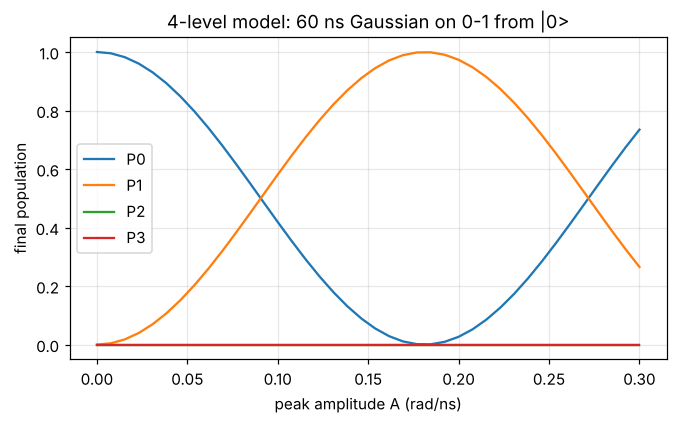

In [5]:
amps = np.linspace(0, 0.3, 40)
pops = sim.rabi_vs_amplitude(dim, H0, H1, amps, tg=60, sigma=15)
fig, ax = plt.subplots(figsize=(7, 3.8))
for k in range(dim):
    ax.plot(amps, pops[:, k], label=f"P{k}")
ax.set(xlabel="peak amplitude A (rad/ns)", ylabel="final population", title="4-level model: 60 ns Gaussian on 0-1 from |0>"); ax.legend()
io.save_fig(fig, "10_rabi_vs_amplitude_4level")

## 5. Phase advance in the simulation (`phase_advance/simulation.ipynb`)

The paper's simulation notebook asked: while a pulse drives 0–1, what happens to the *amplitude* of |2⟩? In the frame rotating at the drive,
|2⟩ is detuned by $\Delta_2 = 2\pi\alpha$, so its amplitude just rotates as $c_2(t) = c_2(0)e^{-i\Delta_2 t}$ — the deterministic phase advance —
plus a small wiggle from the off-resonant 1–2 coupling. Starting from $(|1\rangle + |2\rangle)/\sqrt2$ with a resonant 0–1 pulse:

1-2 coupling off  : max |P2 - 1/2| during the pulse = 0.0001; phase of c2 relative to e^(-i Delta2 t) at the end: -0.0001 rad
1-2 coupling on   : max |P2 - 1/2| during the pulse = 0.0232; phase of c2 relative to e^(-i Delta2 t) at the end: +0.0385 rad


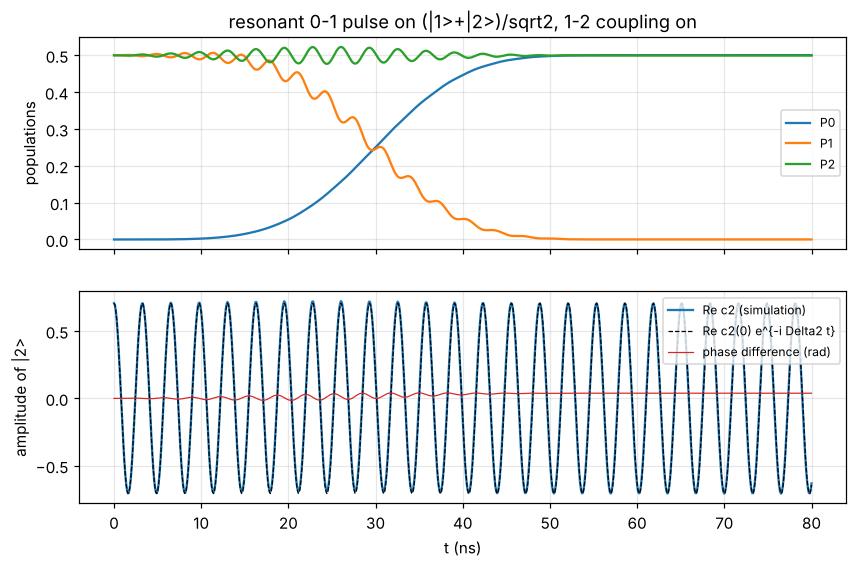

In [6]:
Delta_2 = 2 * pi * (-0.3071)
H0b, H1b = sim.transmon_frame_hamiltonian(3, 4.985, -0.3071, lambdas=[0.54, 0.61])
train = sim.new_pulse_train(); sim.add_pulse(train, "p1", 0, 60, 15, 0.1815)
psi0 = (qt.basis(3, 1) + qt.basis(3, 2)).unit()
for lam1, lab in [(0.0, "1-2 coupling off"), (0.61, "1-2 coupling on")]:
    H0c, H1c = sim.transmon_frame_hamiltonian(3, 4.985, -0.3071, lambdas=[0.54, lam1])
    times, pops, res = sim.simulate_pulse_train(3, H0c, H1c, train, t_end=80, steps=800, psi0=psi0, store_states=True)
    c2 = np.array([res.states[i].full()[2, 0] for i in range(len(times))])
    c2_th = c2[0] * np.exp(-1j * Delta_2 * times)
    phase_err = np.angle(c2 * np.conj(c2_th))
    print(f"{lab:18s}: max |P2 - 1/2| during the pulse = {np.abs(pops[:, 2] - 0.5).max():.4f}; phase of c2 relative to e^(-i Delta2 t) at the end: {phase_err[-1]:+.4f} rad")
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(times, pops); axes[0].set(ylabel="populations", title="resonant 0-1 pulse on (|1>+|2>)/sqrt2, 1-2 coupling on"); axes[0].legend(["P0", "P1", "P2"], fontsize=8)
axes[1].plot(times, np.real(c2), label="Re c2 (simulation)"); axes[1].plot(times, np.real(c2_th), "k--", lw=0.8, label="Re c2(0) e^{-i Delta2 t}")
axes[1].plot(times, phase_err, "C3", lw=0.8, label="phase difference (rad)")
axes[1].set(xlabel="t (ns)", ylabel="amplitude of |2>"); axes[1].legend(fontsize=8)
io.save_fig(fig, "10_phase_advance_simulation")

With the 1–2 coupling on, a 0–1 pulse leaves the |2⟩ amplitude with a phase a few $10^{-2}$ rad away from the free-precession value
(and a transient dip in $P_2$ during the pulse: the "population does not simply acquire a phase — it changes during gate operation" remark of
the simulation notebook). That residual is the α of notebooks 07–08 in the model; the much larger measured values are dominated by the
free precession at $\Delta_2$ during the pulse, $\Delta_2 t_g = 2\pi \times 0.307\,\mathrm{GHz} \times 20\,\mathrm{ns} \approx -38.6$ rad ≡ $-0.9$ rad mod 2π.

In [7]:
print("Delta_2 * 20 ns mod 2pi =", round((Delta_2 * 20) % (2 * pi), 3), "rad;  Delta_2 * 60 ns mod 2pi =", round((Delta_2 * 60) % (2 * pi), 3), "rad (the simulation notebook's -2.677 + 2pi)")

Delta_2 * 20 ns mod 2pi = 5.391 rad;  Delta_2 * 60 ns mod 2pi = 3.607 rad (the simulation notebook's -2.677 + 2pi)


## 6. The master-equation rotation-error sequence (reduced)

`rotation_script.ipynb` fitted the uncorrected rotation-error curve of notebook 04 with the 4-level model, Gaussian pulse trains
of $1 + 2N$ pulses and a 1–2 dephasing rate $\gamma_2$, and found $\epsilon/(\pi/2) \approx 3.7$ % — against 2.7 % from the heuristic
two-parameter model. Here the same simulation is run for $N \le 8$ (a few minutes for the full 40 would be needed) with the amplitude
$A_0 (1 + 0.037)$ of that fit, to show how the drive-frame model produces both the over-rotation *and* an effective phase error from the
off-resonant 0–1 and 2–3 couplings.

final populations (P0, P1, P2, P3) vs N:


 [[0.    0.467 0.533 0.   ]
 [0.    0.335 0.665 0.   ]
 [0.    0.217 0.783 0.   ]
 [0.    0.121 0.878 0.   ]
 [0.    0.055 0.944 0.001]]


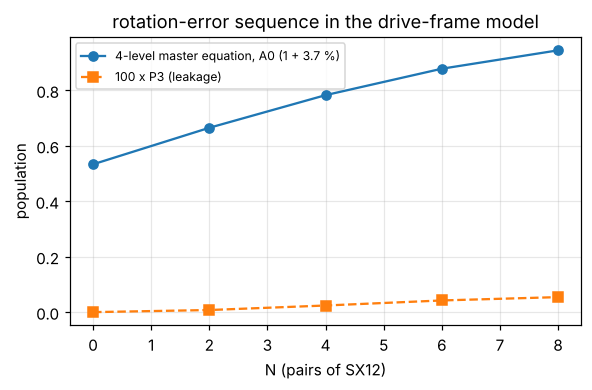

In [8]:
from scipy.optimize import curve_fit
f_q, f_a = 4.985, -0.3071
delta = -2 * pi * f_a                     # drive on resonance with 1-2: delta = omega01 - omega_d = -Delta_2
H0d, H1d = sim.transmon_frame_hamiltonian(4, f_q, f_a, lambdas=[0.089, 0.0987, 0.15], delta=delta)
H0d = H0d - np.eye(4) * 0                # (energies relative to |0>)
c_ops = sim.collapse_operators(4, gamma_2=8.008e-5)
A0 = 0.2383838 * (1 + 0.037) * 2 * pi
N_list = np.arange(0, 9, 2)
p2_sim = []
for Nn in N_list:
    train = sim.new_pulse_train()
    sim.add_pulse(train, "p0", 0, 20, 5, A0)
    for i in range(Nn):
        sim.add_pulse(train, f"p{i}a", train["clock"], 20, 5, A0)
        sim.add_pulse(train, f"p{i}b", train["clock"], 20, 5, A0)
    times, pops, _ = sim.simulate_pulse_train(4, H0d, H1d, train, steps=40 * (1 + 2 * Nn), c_ops=c_ops, psi0=qt.basis(4, 1))
    p2_sim.append(pops[-1])
p2_sim = np.array(p2_sim)
print("final populations (P0, P1, P2, P3) vs N:\n", np.round(p2_sim, 3))
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(N_list, p2_sim[:, 2], "o-", label="4-level master equation, A0 (1 + 3.7 %)")
ax.plot(N_list, p2_sim[:, 3] * 100, "s--", label="100 x P3 (leakage)")
ax.set(xlabel="N (pairs of SX12)", ylabel="population", title="rotation-error sequence in the drive-frame model"); ax.legend(fontsize=8)
io.save_fig(fig, "10_master_equation_rotation_error")

The model's $P_2$ already drifts upward over the first pairs as the measured curve does (notebook 04, Fig. 1a), and the leakage to |3⟩ stays at
the $10^{-3}$ level for this pulse. Extending `N_list` to 40 and wrapping the loop in `scipy.optimize.minimize` over $(\gamma_2, A_0)$ reproduces
the fit of `rotation_script.ipynb`; the `lambdas` used there (0.089, 0.0987, 0.15) were themselves fitted to the measured Rabi frequencies.